In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Construct the Graph

In [2]:
# Define a graph with 5 nodes.
n = 5
V = np.arange(0, n, 1)
# Define edges with weights in the format (node1, node2, weight)
E = [(0, 1, 1.0), (0, 2, 1.0), (1, 2, 1.0), (3, 2, 1.0), (3, 4, 1.0), (4, 2, 1.0)]

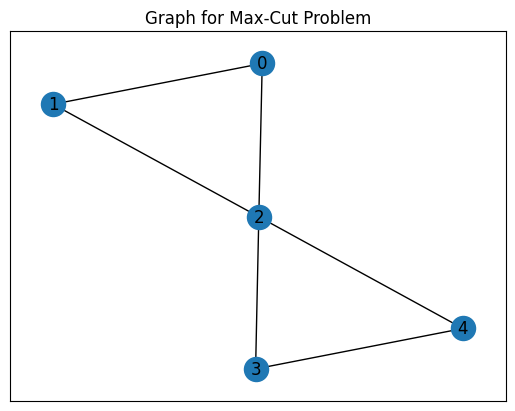

In [3]:
# Create an empty undirected graph
G = nx.Graph()
G.add_nodes_from(V)
G.add_weighted_edges_from(E)

# Visualize the graph
nx.draw_networkx(G)
plt.title("Graph for Max-Cut Problem")
plt.show()



# 2. Classical Preprocessing to Determine QAOA Parameters

In [4]:
# Set a step size for grid search over angles gamma and beta.
step_size = 0.1
# Create ranges for gamma and beta from 0 to pi.
a_gamma = np.arange(0, np.pi, step_size)
a_beta = np.arange(0, np.pi, step_size)
# Create a meshgrid for exploring all combinations.
a_gamma, a_beta = np.meshgrid(a_gamma, a_beta)

# Define an objective function F1 based on the chosen angles.
# This is an example function that might represent the expected value of the cost function.
F1 = 3 - (np.sin(2 * a_beta) ** 2 * np.sin(2 * a_gamma) ** 2 -
          0.5 * np.sin(4 * a_beta) * np.sin(4 * a_gamma)) * (1 + np.cos(4 * a_gamma) ** 2)

# Find the indices corresponding to the maximum value in F1.
result = np.where(F1 == np.amax(F1))
# Convert grid indices back to gamma and beta values.
gamma = result[0][0] * step_size
beta = result[1][0] * step_size

print(f"Selected gamma: {gamma}, beta: {beta}")



Selected gamma: 1.9000000000000001, beta: 0.2


# 3. Install and Import Qiskit for Circuit Creation and Visualization

In [5]:
!pip install 'qiskit[visualization]'  # Installs Qiskit and visualization tools

from qiskit import QuantumCircuit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 131.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 11.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=12082c06976b2d17bead547699aecf9a8f769e7c2602948585383a48b87615f4
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


# 4. Construct the QAOA Quantum Circuit

In [6]:
# Initialize a QuantumCircuit with one qubit per node and classical bits for measurement.
QAOA = QuantumCircuit(len(V), len(V))

# Apply Hadamard gates to all qubits to create a uniform superposition.
QAOA.h(range(len(V)))
QAOA.barrier()

# Apply the cost unitary U(C, gamma) using controlled-phase gates (cp) and phase shifts (p).
for edge in E:
    k, l, _ = edge
    QAOA.cp(-2 * gamma, k, l)
    QAOA.p(gamma, k)
    QAOA.p(gamma, l)

# Apply a barrier for clarity in the circuit diagram.
QAOA.barrier()

# Apply the mixing unitary U(B, beta) using RX rotation gates.
QAOA.rx(2 * beta, range(len(V)))

# Add another barrier and then measure the qubits into the classical bits.
QAOA.barrier()
QAOA.measure(range(len(V)), range(len(V)))

# Draw the circuit as text for a quick overview.
print(QAOA.draw(output='text'))



     ┌───┐ ░           ┌────────┐          ┌────────┐                    »
q_0: ┤ H ├─░──■────────┤ P(1.9) ├─■────────┤ P(1.9) ├────────────────────»
     ├───┤ ░  │P(-3.8) ├────────┤ │        └────────┘          ┌────────┐»
q_1: ┤ H ├─░──■────────┤ P(1.9) ├─┼───────────────────■────────┤ P(1.9) ├»
     ├───┤ ░           └────────┘ │P(-3.8) ┌────────┐ │P(-3.8) ├────────┤»
q_2: ┤ H ├─░──────────────────────■────────┤ P(1.9) ├─■────────┤ P(1.9) ├»
     ├───┤ ░                               └────────┘          └────────┘»
q_3: ┤ H ├─░─────────────────────────────────────────────────────────────»
     ├───┤ ░                                                             »
q_4: ┤ H ├─░─────────────────────────────────────────────────────────────»
     └───┘ ░                                                             »
c: 5/════════════════════════════════════════════════════════════════════»
                                                                         »
«                        

# 5. Install and Configure Qiskit IBM Runtime

Selected backend: <IBMBackend('ibm_brisbane')>


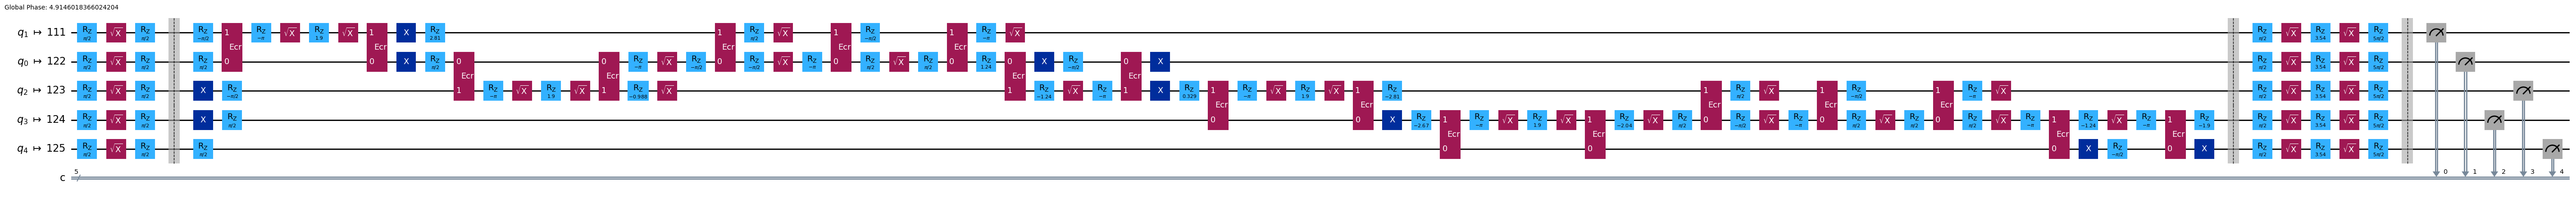

In [9]:
!pip install qiskit_ibm_runtime

from qiskit_ibm_runtime import QiskitRuntimeService

# Save your IBM Quantum account credentials.
# Replace <MY_IBM_QUANTUM_TOKEN> with your actual token.
QiskitRuntimeService.save_account(channel="ibm_quantum", token="16b4deed20c24abc59edc6c586b131f9195458d1c74c9ebd9c7569ae81f2c67e2f3e105c37365c4f5f831b5ab998c80afd10204e37f44211f0a0a7cbdbca0555", overwrite=True, set_as_default=True)

# Get the IBM Quantum runtime service
service = QiskitRuntimeService(channel='ibm_quantum')


# the Max-Cut problem for our example only requires 5 qubits,
# we optionally chose a least busy backend with at least 127 qubits to ensure availability and performance.


backend = service.least_busy(min_num_qubits=127)
print("Selected backend:", backend)



from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Generate a preset pass manager for optimization level 3 targeting the selected backend.

"""
The pass manager helps optimize the quantum circuit for the selected backend.
'optimization_level=3' applies a high level of optimization.
Specifying the 'backend' ensures that the circuit is tailored to the target hardware.
"""

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# Transpile the circuit using the pass manager
candidate_circuit = pm.run(QAOA)
# Visualize the transpiled circuit using matplotlib.
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

# 6. Execute the Circuit on the Backend Using Qiskit IBM Runtime Sampler


In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler


sampler = Sampler(mode=backend)

# Set up error suppression/mitigation options.
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

# Prepare the circuit in a tuple (as expected by the sampler)
pub = (candidate_circuit,)

# Execute the circuit with a specified number of shots (here, 10,000)
job = sampler.run([pub], shots=int(1e4))

# Retrieve and print basic job information
print("Job:", job)
print("Job Backend:", job.backend())

Job: <RuntimeJobV2('czt4p3rd8drg008h19h0', 'sampler')>
Job Backend: <IBMBackend('ibm_brisbane')>


# 7. Retrieve the Results and Extract Measurement Counts

In [11]:
job_result = job.result()
# The result for the circuit is contained in a list; here we access the first result.
job_data = job_result[0].data.c
# Extract the counts (measurement outcomes and their corresponding frequencies)
counts = job_data.get_counts()

print("Measurement Counts:")
print(counts)



Measurement Counts:
{'10100': 302, '10011': 364, '11010': 353, '11001': 376, '00110': 353, '10101': 335, '01010': 388, '01100': 369, '10111': 284, '10010': 363, '00010': 260, '00111': 302, '00101': 322, '11111': 241, '11100': 250, '11000': 266, '00100': 331, '01110': 351, '10001': 337, '10110': 276, '11110': 261, '01011': 313, '01000': 305, '00000': 214, '00011': 221, '01001': 375, '11011': 341, '01111': 321, '00001': 270, '10000': 300, '01101': 362, '11101': 294}


# 8. Plot the Measurement Counts

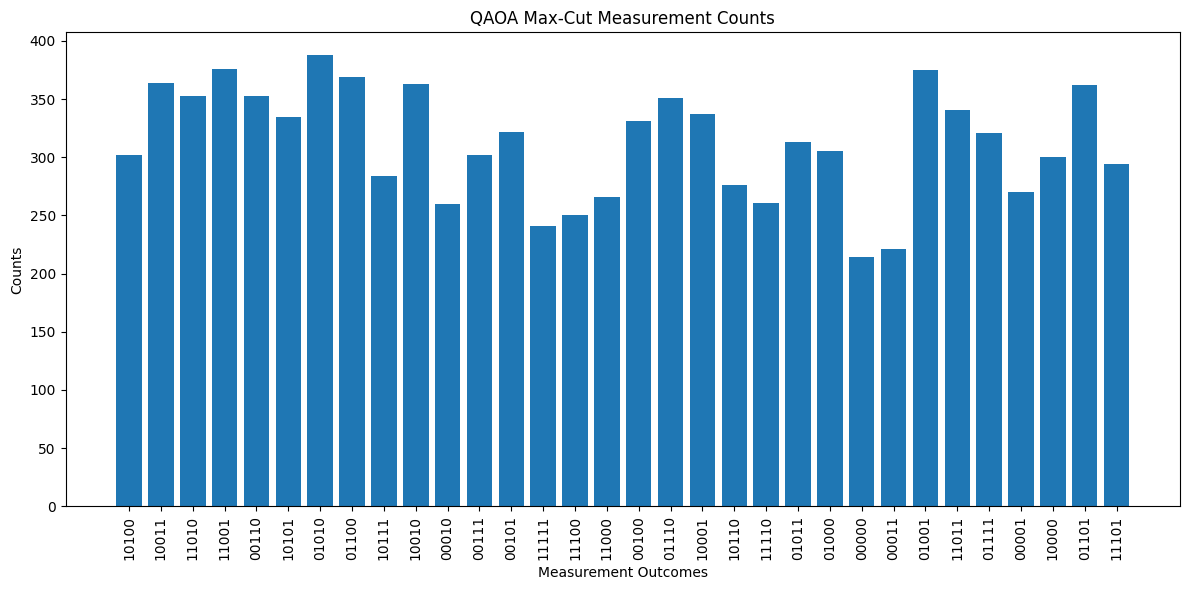

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel('Measurement Outcomes')
plt.ylabel('Counts')
plt.title('QAOA Max-Cut Measurement Counts')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()